<center>
<img src="../images/fscampus_small2.png" width="1200"/>
</center>


***Finance I (OFIN)-SS2026***

**Dr. Omer Cayirli**

Lecturer in Empirical Finance

omer.cayirli@vgu.edu.vn

---

## Lecture 03
---

### Outline
####   Investment Decision Rules
  *   NPV Investment Rule
  *   IRR Investment Rule
  *   Payback Investment Rule
  *   Profitability Index
  *   Project Selection
---

### Investment Decision Rules
*   Net Present Value:
    *   Present value of future cash flows minus initial investment(s).
*   Opportunity Cost of Capital (r)
    *   Expected rate of return given up by investing in a project.

$$
NPV = C_0 + \frac{C_1}{(1+r)^1} + \frac{C_2}{(1+r)^2} + ... + \frac{C_t}{(1+r)^t}
$$

*   $C_0$: the initial cash outflow (usually negative)
*   $C_t$: the net cash flow generated
*   t = time period of the investment
*   r = "opportunity cost of capital"

The cash flow can be positive or negative at any time period.

---

### Investment Decision Rules: Net Present Value Rule

*   When making an investment decision, take the alternative with the highest NPV. Choosing this alternative is equivalent to receiving its NPV in cash today.

*   Accept projects with a positive net present value.
        *   NPV = -PV(Cost) + PV(Benefits)
        *   NPV > 0: Accept
        *   NPV < 0: Reject

You are offered an investment in a land that costs $\$250,000$ today and expected to have a value of $\$280,000$ in one year. A guaranteed bank deposit offers 10% interest for one year and the interest rate in similar alternative investments is 20%. Should you accept this offer?

*   NPV = -PV(Cost) + PV(Benefits)
*   NPV = −250,000 + 280,000 / (1+0.10) = $4,545.45
*   NPV = -250,000 + 280,000 / (1+0.20) = -$16,666.67

---

### Investment Decision Rules: Internal Rate of Return (IRR)

* Discount rate at which NPV = 0.

$$
NPV = C_0 + \frac{C_1}{(1+ IRR)^1} + \frac{C_2}{(1 + IRR)^2} + ... + \frac{C_t}{(1+ IRR)^t} = 0
$$

Where:
*   $C_0$: the initial cash outflow
*   $C_t$: the net cash flow generated
*   t : time period of the investment

---

### Investment Decision Rules: Internal Rate of Return (IRR) Investment Rule

*   Take an investment when the IRR exceeds the cost of capital
    *   IRR > "opportunity cost of capital r" (NPV>0)
*   Turn down an investment when IRR is less than the cost of capital
    *   IRR < "opportunity cost of capital r" (NPV <0)
*   The IRR Investment Rule will give the same answer as the NPV rule in many, but not all, situations.

*   In general, the IRR rule works for a stand-alone project if all the project's negative cash flows precede its positive cash flows. If this is not the case, the IRR rule may lead to incorrect decisions.
---

### Investment Decision Rules
*   The NPV Profile and IRR
    *   The NPV of a project depends on the appropriate cost of capital.
    *   There may be some uncertainty regarding the project's cost of capital.
    *   In that case, it is helpful to compute an NPV profile.
<center>
<img src="../figures/npv_profile_01.png" width="720"/>
</center>

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- Core Functions ---

def calculate_npv(initial_investment, cash_flows, discount_rate):
    npv = -initial_investment
    for i, cash_flow in enumerate(cash_flows):
        npv += cash_flow / (1 + discount_rate)**(i + 1)
    return npv

def calculate_irr(initial_investment, cash_flows):
    def npv_equation(rate):
        return -initial_investment + sum(cash_flows[i] / (1 + rate)**(i + 1) for i in range(len(cash_flows)))
    try:
        irr_solution = fsolve(npv_equation, 0.1)
        irr = irr_solution[0]
        return irr if irr > -1 else None
    except Exception:
        return None

def plot_npv_schedule(initial_investment, cash_flows, irr, bank_rate, alt_rate):
    discount_rates = np.linspace(0, max(0.4, (irr if irr else 0) * 1.5, bank_rate * 1.5, alt_rate * 1.5), 100)
    npv_values = [calculate_npv(initial_investment, cash_flows, rate) for rate in discount_rates]
    
    plt.figure(figsize=(10, 5))
    plt.plot(discount_rates * 100, npv_values, color='blue', lw=2, label='NPV Schedule')
    plt.axhline(0, color='black', linestyle='-', linewidth=1)
    
    if irr is not None:
        plt.axvline(irr * 100, color='red', linestyle='--', label=f'IRR = {irr*100:.2f}%')
        plt.scatter([irr * 100], [0], color='red', zorder=5)

    plt.axvline(bank_rate * 100, color='green', linestyle=':', label=f'Bank Rate ({bank_rate*100:.1f}%)')
    plt.axvline(alt_rate * 100, color='orange', linestyle=':', label=f'Alt Rate ({alt_rate*100:.1f}%)')
    
    plt.title('NPV Profile: Sensitivity to Discount Rate')
    plt.xlabel('Discount Rate (%)')
    plt.ylabel('Net Present Value ($)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

# --- Interactive Wrapper ---

def run_analysis(investment, cf_string, bank_r, alt_r):
    # Parse the cash flow string into a list of floats
    try:
        c_flows = [float(x.strip()) for x in cf_string.split(',')]
    except ValueError:
        print("Error: Please enter cash flows as numbers separated by commas (e.g., 280000, 50000)")
        return

    # Calculations
    bank_rate = bank_r / 100
    alt_rate = alt_r / 100
    npv_bank = calculate_npv(investment, c_flows, bank_rate)
    npv_alt = calculate_npv(investment, c_flows, alt_rate)
    irr_val = calculate_irr(investment, c_flows)

    # UI Output
    clear_output(wait=True)
    display(ui) # Keep controls visible
    
    print("\n" + "="*40)
    print(" INVESTMENT ANALYSIS RESULTS")
    print("="*40)
    print(f"NPV at Bank Rate ({bank_r}%): ${npv_bank:,.2f}")
    print(f"NPV at Alt Rate ({alt_r}%):  ${npv_alt:,.2f}")
    
    if irr_val is not None:
        print(f"Internal Rate of Return:    {irr_val*100:.2f}%")
        
        print("\nDecision Recommendations:")
        if npv_bank > 0:
            print(f"✅ Profitable relative to the bank deposit.")
        else:
            print(f"❌ NOT profitable relative to the bank deposit.")
            
        if npv_alt > 0:
            print(f"✅ Profitable relative to alternative investments.")
        else:
            print(f"❌ NOT profitable relative to alternative investments.")
    else:
        print("\nIRR could not be calculated for this scenario.")
    
    print("-" * 40)
    plot_npv_schedule(investment, c_flows, irr_val, bank_rate, alt_rate)

# --- Define Widgets ---

style = {'description_width': 'initial'}

investment_input = widgets.FloatText(
    value=250000, description='Initial Investment ($):', style=style)

cash_flow_input = widgets.Text(
    value='280000', description='Cash Flows (comma-separated):', style=style)

bank_rate_slider = widgets.FloatSlider(
    value=10.0, min=0, max=50.0, step=0.5, description='Bank Rate (%):', style=style)

alt_rate_slider = widgets.FloatSlider(
    value=20.0, min=0, max=50.0, step=0.5, description='Alt Investment Rate (%):', style=style)

# --- Layout and Display ---

ui = widgets.VBox([
    widgets.HTML("<b>Enter Investment Parameters:</b>"),
    investment_input, 
    cash_flow_input, 
    bank_rate_slider, 
    alt_rate_slider
])

out = widgets.interactive_output(run_analysis, {
    'investment': investment_input,
    'cf_string': cash_flow_input,
    'bank_r': bank_rate_slider,
    'alt_r': alt_rate_slider
})

display(ui, out)

Output()

---

### Investment Decision Rules
*   Situations in which the IRR rule and NPV rule may be in conflict:
    
    *   Delayed Investments (aka lending vs. borrowing)
    
    *   Nonexistent IRR
    
    *   Multiple IRRs
*   Delayed Investments
    
    *   For most investment opportunities, expenses occur initially, and cash is received later.
    
    *   For delayed investments, cash is received upfront, and the costs are incurred later.
    
    *   This is akin to receiving cash today in exchange for a future liability, for which you would prefer as low a rate as possible.
    
    *   So optimal rule is to borrow money as long as this rate is less than the cost of capital.

---

### Example 3.1

*   Having retired from your executive role, you're considering a long-term consulting engagement. A client proposes to pay you a **$800,000** retainer upfront if you commit to a three-year project.

    *   This project will require your full attention for the next three years.
    
    *   Focusing on this engagement means you'll have to turn down other potential consulting opportunities that would have collectively earned you **$300,000** per year.
    
    *   Given the risk profile of alternative consulting projects and your investment options, your opportunity cost of capital is estimated to be **8%**.

### Solution
**NPV**
$$
\text{PV}_{\text{lost}} = 300,\!000 \times \frac{1 - (1 + 0.08)^{-3}}{0.08} \qquad \text{PV}_{\text{lost}} = 300,\!000 \times 2.577097 \approx 773,\!129.10
$$
$$
\text{NPV} = 800,\!000 - 773,\!129.10 \approx 26,\!870.90
$$
**IRR**
$$
800,\!000 - \frac{300,\!000}{1+i} - \frac{300,\!000}{(1+i)^2} - \frac{300,\!000}{(1+i)^3} = 0 \qquad \rightarrow \qquad i \approx 0.0613 \quad \text{or} \quad 6.13\%$$


$\rightarrow$ **When the benefits of an investment occur before the costs, the NPV is an *increasing* function of the discount rate.**

---

In [2]:
import numpy_financial as npf

# Cash flows
cash_flows = [800000, -300000, -300000, -300000]  # t=0: retainer, t=1,2,3: forgone income
discount_rate = 0.08  # 8%

# Calculate NPV
npv = npf.npv(discount_rate, cash_flows)

# Print result
print(f"NPV of the consulting project: ${npv:,.2f}")

# Decision
if npv > 0:
    print("Since NPV is positive, you should accept the consulting offer.")
else:
    print("Since NPV is negative, you should reject the consulting offer.")

irr = npf.irr(cash_flows)
print(f"IRR: {irr*100:.2f}%")

NPV of the consulting project: $26,870.90
Since NPV is positive, you should accept the consulting offer.
IRR: 6.13%


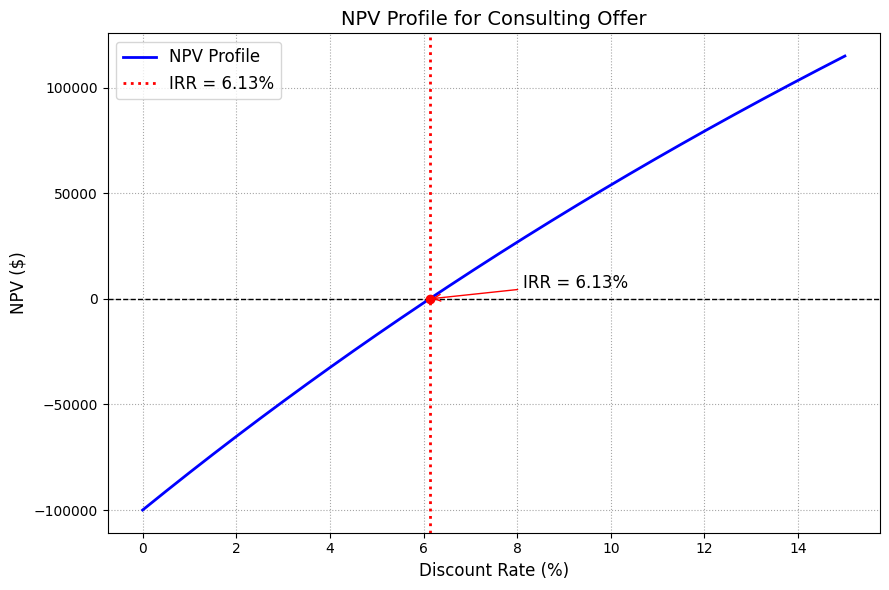

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Define the cash flows for the consulting offer
CF0 = 800000      # cash inflow at time 0
CF1 = -300000     # lost consulting fee at end of Year 1
CF2 = -300000     # lost consulting fee at end of Year 2
CF3 = -300000     # lost consulting fee at end of Year 3

# Define the NPV function as a function of the discount rate r (in decimal)
def npv(r):
    return CF0 + CF1/(1+r) + CF2/(1+r)**2 + CF3/(1+r)**3

# Create a range of discount rates from 0% to 15%
r_vals = np.linspace(0, 0.15, 300)
npv_vals = np.array([npv(r) for r in r_vals])

# Compute the IRR by solving for r such that NPV = 0.
# We solve the equation: CF0 + CF1/(1+r) + CF2/(1+r)**2 + CF3/(1+r)**3 = 0.
# Multiply both sides by (1+r)**3 to obtain a polynomial:
#   CF0*(1+r)**3 + CF1*(1+r)**2 + CF2*(1+r) + CF3 = 0.
# Let x = 1 + r, then the equation becomes:
#   CF0*x^3 + CF1*x^2 + CF2*x + CF3 = 0.
# Solve for x and then IRR = x - 1.

coeffs = [CF0, CF1, CF2, CF3]  # coefficients of x^3, x^2, x, and constant term
roots = np.roots(coeffs)
# Select the real root greater than 1 (since x = 1+r, and r > 0)
x_val = None
for root in roots:
    if np.isreal(root) and root.real > 1:
        x_val = root.real
        break

IRR = x_val - 1 if x_val is not None else None

# Plot the NPV profile
plt.figure(figsize=(9, 6))
plt.plot(r_vals * 100, npv_vals, label='NPV Profile', color='blue', lw=2)
plt.axhline(0, color='black', linestyle='--', lw=1)  # horizontal line at NPV=0

if IRR is not None:
    # Draw a vertical dotted line at the IRR
    plt.axvline(IRR * 100, color='red', linestyle=':', lw=2, label=f'IRR = {IRR*100:.2f}%')
    # Mark the IRR point on the curve
    plt.plot(IRR * 100, 0, 'ro')
    plt.annotate(f'IRR = {IRR*100:.2f}%', 
                 xy=(IRR * 100, 0), 
                 xytext=(IRR * 100 + 2, 5000),
                 arrowprops=dict(arrowstyle="->", color='red'),
                 fontsize=12)

plt.xlabel('Discount Rate (%)', fontsize=12)
plt.ylabel('NPV ($)', fontsize=12)
plt.title('NPV Profile for Consulting Offer', fontsize=14)
plt.grid(True, linestyle=':', color='gray', alpha=0.7)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()


---

### Investment Decision Rules
*   Multiple IRRs
    
    *   A cash flow stream with K changes in sign can have up to K sensible internal rates of return.
    
    *   For instance, initial investment (-), profits (+), and further investment (-)
    
    *   In our example the cash flows were (800,000, -300,000, -300,000, -300,000)
    
    *   Now assume that the payment structure has changed to (325,000, -300,000, -300,000, -300,000, 600,000) (+, -, -, -, +)

---

Calculated IRRs (High Precision):
IRR 1: 5.484841%
IRR 2: 37.108825%


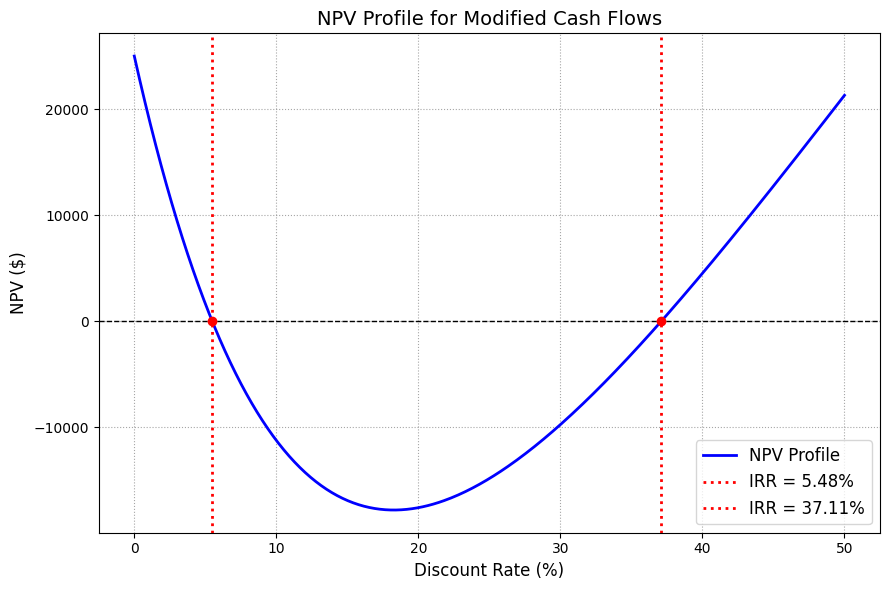

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Modified cash flows:
CF0 = 325000   # Modified Time 0 cash flow
CF1 = -300000  # Time 1
CF2 = -300000  # Time 2
CF3 = -300000  # Time 3
CF4 = 600000   # Time 4

# Define the NPV function for a given discount rate r (in decimal)
def npv(r):
    return (CF0 +
            CF1 / (1 + r) +
            CF2 / (1 + r)**2 +
            CF3 / (1 + r)**3 +
            CF4 / (1 + r)**4)

# -----------------------------------------------------------
# Solve for IRRs using the polynomial approach.
# The NPV equation multiplied by (1+r)^4 is:
#   CF0*(1+r)^4 + CF1*(1+r)^3 + CF2*(1+r)^2 + CF3*(1+r) + CF4 = 0.
# Let x = 1 + r, then:
#   CF0*x^4 + CF1*x^3 + CF2*x^2 + CF3*x + CF4 = 0.
coeffs = [CF0, CF1, CF2, CF3, CF4]
roots = np.roots(coeffs)

# Extract the real roots and convert back to r = x - 1.
IRRs = []
for root in roots:
    if np.isreal(root):
        x_val = np.real(root)
        r_val = x_val - 1
        # Only consider IRRs that are strictly > 0.
        if r_val > 0:
            IRRs.append(r_val)
IRRs.sort()

print("Calculated IRRs (High Precision):")
for idx, irr in enumerate(IRRs, start=1):
    print(f"IRR {idx}: {irr*100:.6f}%")

# -----------------------------------------------------------
# Generate the NPV profile over a range of discount rates (0% to 50%)
r_vals = np.linspace(0, 0.50, 400)
npv_vals = np.array([npv(r) for r in r_vals])

plt.figure(figsize=(9, 6))
plt.plot(r_vals * 100, npv_vals, label='NPV Profile', color='blue', lw=2)
plt.axhline(0, color='black', linestyle='--', lw=1)

# Mark each IRR on the plot with a vertical dotted line and a red marker at NPV = 0
for irr in IRRs:
    plt.axvline(irr * 100, color='red', linestyle=':', lw=2, label=f'IRR = {irr*100:.2f}%')
    plt.plot(irr * 100, 0, 'ro')

plt.xlabel('Discount Rate (%)', fontsize=12)
plt.ylabel('NPV ($)', fontsize=12)
plt.title('NPV Profile for Modified Cash Flows', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle=':', color='gray', alpha=0.7)
plt.tight_layout()
plt.show()



---

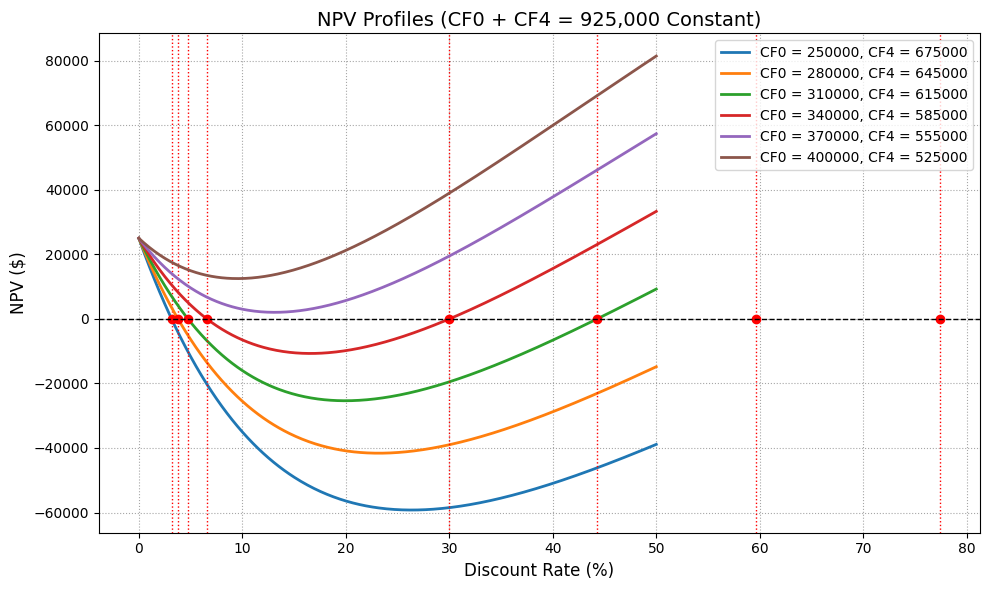

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------------------------------
# Simulation Parameters:
# -----------------------------------------------------------
# We want to keep the sum CF0 + CF4 constant.
total = 925000   # Constant total for CF0 and CF4

# Other cash flows (fixed)
CF1 = -300000    # Time 1
CF2 = -300000    # Time 2
CF3 = -300000    # Time 3

# We'll simulate by varying CF0 and adjusting CF4 = total - CF0.
CF0_values = np.linspace(250000, 400000, 6)  # e.g., 6 scenarios from 250k to 400k

# Define a range of discount rates (in decimal form) for the NPV profile.
r_vals = np.linspace(0, 0.50, 400)

# -----------------------------------------------------------
# Define Functions:
# -----------------------------------------------------------
def npv_profile(r, CF0, CF4):
    """
    Calculate the NPV at discount rate r for the cash flow sequence:
    CF0, CF1, CF2, CF3, CF4.
    """
    return (CF0 +
            CF1 / (1 + r) +
            CF2 / (1 + r)**2 +
            CF3 / (1 + r)**3 +
            CF4 / (1 + r)**4)

def compute_irrs(CF0, CF4):
    """
    Compute IRRs for the cash flow sequence using the polynomial approach.
    We solve for r in the equation:
      CF0*(1+r)^4 + CF1*(1+r)^3 + CF2*(1+r)^2 + CF3*(1+r) + CF4 = 0,
    by letting x = 1+r.
    Returns a sorted list of positive IRRs (as decimals).
    """
    coeffs = [CF0, CF1, CF2, CF3, CF4]
    roots = np.roots(coeffs)
    irr_list = []
    for root in roots:
        if np.isreal(root):
            x_val = np.real(root)
            r_val = x_val - 1
            if r_val > 0:
                irr_list.append(r_val)
    irr_list.sort()
    return irr_list

# -----------------------------------------------------------
# Simulation: For each CF0 (and corresponding CF4), compute the NPV profile and IRRs.
# -----------------------------------------------------------
plt.figure(figsize=(10, 6))

for CF0_val in CF0_values:
    CF4_val = total - CF0_val  # Ensure CF0 + CF4 remains constant
    # Compute NPV profile for this scenario.
    npv_vals = np.array([npv_profile(r, CF0_val, CF4_val) for r in r_vals])
    
    # Compute IRRs for this cash flow sequence.
    irrs = compute_irrs(CF0_val, CF4_val)
    
    # Label for this scenario.
    label_text = f'CF0 = {CF0_val:.0f}, CF4 = {CF4_val:.0f}'
    plt.plot(r_vals * 100, npv_vals, label=label_text, lw=2)
    
    # Mark each IRR on the profile with a red circle and vertical dotted line.
    for irr in irrs:
        plt.plot(irr * 100, 0, 'ro')
        plt.axvline(irr * 100, linestyle=':', color='red', lw=1)

# Plot horizontal line at NPV = 0.
plt.axhline(0, color='black', linestyle='--', lw=1)

plt.xlabel('Discount Rate (%)', fontsize=12)
plt.ylabel('NPV ($)', fontsize=12)
plt.title('NPV Profiles (CF0 + CF4 = 925,000 Constant)', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, linestyle=':', color='gray', alpha=0.7)
plt.tight_layout()
plt.show()


---

### Example 3.2

Main Street Development Corp. is evaluating the construction of a new regional distribution warehouse.
* The initial cost to acquire the land and build the facility is \$12 million today.
* The warehouse is expected to generate net rental income of \$1.8 million per year for a 20-year period.
* After the 20-year primary use period, the building will be retired from operations. However, due to a long-term ground lease and site security requirements, the company will face ongoing costs of \$150,000 per year in perpetuity.
* Assume all cash flows occur at the end of the year and the cost of capital is 6%.

    *  What is the NPV of this investment? Should the firm proceed with the project?
    *  How many IRRs does this investment opportunity potentially have?
    *  Can the IRR rule be reliably used to evaluate this investment?

---

### Example 3.2: Solution

$NPV = -PV(\text{Initial Cost}) + PV(\text{Rental Income}) - PV(\text{Perpetual Tail})$

**PV of Rental Income (Years 1–20):**

$$PV_{1-20} = 1,800,000 \times \left[ \frac{1 - (1.06)^{-20}}{0.06} \right] \quad \Rightarrow \quad PV_{1-20} = 1,800,000 \times 11.4699212248 \approx \$20,645,858.20$$

**PV of Perpetual Tail (Starting Year 21):**
$$PV_{\text{perp},20} = \frac{-150,000}{0.06} = -\$2,500,000.00$$

Discount this value back 20 years to the present ($t=0$):
$$PV_{\text{perp},0} = \frac{-2,500,000}{(1.06)^{20}} \approx \frac{-2,500,000}{3.2071354722} \approx -\$779,511.76$$

**Total NPV:**
$$NPV = -12,000,000 + 20,645,858.20 - 779,511.76 = \$7,866,346.44$$

#### IRR Analysis
*   **Time 0:** $CF_0 = -\$12,000,000$ (Negative)
*   **Years 1 to 20:** $CF_t = +\$1,800,000$ (Positive)
*   **Years 21 onward:** $CF_t = -\$150,000$ (Negative)

There are two sign changes in the cash flow sequence (from $-$ to $+$, then from $+$ to $-$). This project can have up to two internal rates of return (IRRs). 

Because the project has non-conventional cash flows resulting in multiple possible IRRs, the IRR rule is not reliable here. 

---

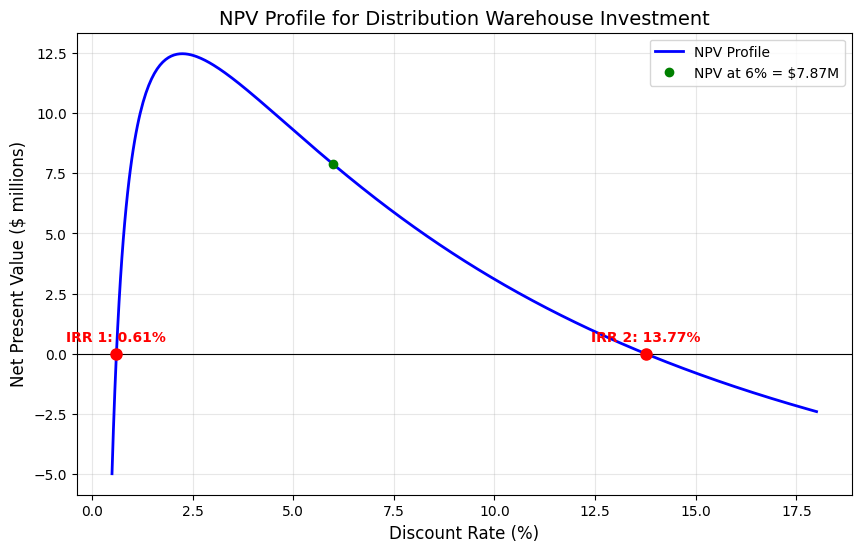

INVESTMENT ANALYSIS: DISTRIBUTION WAREHOUSE
NPV at 6.0% Cost of Capital: $7,866,346.38
Decision: ✅ ACCEPT project

INTERNAL RATE OF RETURN (IRR) SUMMARY:
  IRR 1: 0.61%
  IRR 2: 13.77%

RELIABILITY ASSESSMENT:
⚠️ The IRR rule is NOT RELIABLE for this project.
Reason: Multiple IRRs exist due to non-conventional cash flows (-, +, -).
--------------------------------------------------


In [5]:
import numpy as np
from scipy.optimize import fsolve
import matplotlib.pyplot as plt

# --- 1. NPV Function Definition ---
def calculate_net_npv(rate):
    epsilon = 1e-12
    safe_rate = rate if abs(rate) > epsilon else epsilon
    
    # Project Parameters (Exercise 3.2: Distribution Warehouse)
    initial_investment = -12000000  # $12 million
    net_inflow = 1800000           # $1.8 million
    annuity_years = 20             # 20 years
    perpetuity_cost = 150000       # $150,000
    
    # Components
    pv_annuity = net_inflow * (1 - (1 + safe_rate)**(-annuity_years)) / safe_rate
    pv_perpetuity_at_t20 = perpetuity_cost / safe_rate
    pv_perpetuity_at_t0 = pv_perpetuity_at_t20 / (1 + safe_rate)**annuity_years
    
    return initial_investment + pv_annuity - pv_perpetuity_at_t0

# --- 2. Calculations ---
cost_of_capital = 0.06
npv_at_coc = calculate_net_npv(cost_of_capital)

# Find IRRs using numerical guesses
try:
    # Based on the (-, +, -) sign change pattern, we test two regions
    irr_1 = fsolve(calculate_net_npv, 0.015)[0]
    irr_2 = fsolve(calculate_net_npv, 0.14)[0]
    # Filter for unique results and round for comparison
    found_irrs = sorted(list(set([round(irr_1, 6), round(irr_2, 6)])))
except:
    found_irrs = []

# --- 3. Plotting the NPV Profile ---
rates = np.linspace(0.005, 0.18, 500)  # 0.5% to 18%
# Corrected the variable name here from 'n' to 'r'
npvs_millions = [calculate_net_npv(r) / 1e6 for r in rates] 

plt.figure(figsize=(10, 6))
plt.plot(rates * 100, npvs_millions, label='NPV Profile', color='blue', linewidth=2)
plt.axhline(0, color='black', linestyle='-', linewidth=0.8)

# Mark the IRRs on the curve
for i, irr in enumerate(found_irrs):
    plt.plot(irr * 100, 0, 'ro', markersize=8)
    plt.annotate(f'IRR {i+1}: {irr*100:.2f}%', (irr * 100, 0.5), 
                 color='red', fontweight='bold', ha='center')

# Mark NPV at 6%
plt.plot(cost_of_capital * 100, npv_at_coc / 1e6, 'go', 
         label=f'NPV at 6% = ${npv_at_coc/1e6:,.2f}M')

plt.title('NPV Profile for Distribution Warehouse Investment', fontsize=14)
plt.xlabel('Discount Rate (%)', fontsize=12)
plt.ylabel('Net Present Value ($ millions)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()

# Display the plot FIRST
plt.show()

# --- 4. Printed Analysis (Displayed SECOND) ---
print("="*50)
print("INVESTMENT ANALYSIS: DISTRIBUTION WAREHOUSE")
print("="*50)
print(f"NPV at {cost_of_capital*100:.1f}% Cost of Capital: ${npv_at_coc:,.2f}")
print(f"Decision: {'✅ ACCEPT project' if npv_at_coc > 0 else '❌ REJECT project'}")

print("\nINTERNAL RATE OF RETURN (IRR) SUMMARY:")
if len(found_irrs) > 1:
    for i, val in enumerate(found_irrs):
        print(f"  IRR {i+1}: {val*100:.2f}%")
    print("\nRELIABILITY ASSESSMENT:")
    print("⚠️ The IRR rule is NOT RELIABLE for this project.")
    print("Reason: Multiple IRRs exist due to non-conventional cash flows (-, +, -).")
elif len(found_irrs) == 1:
    print(f"  Single IRR: {found_irrs[0]*100:.2f}%")
    print("\nRELIABILITY ASSESSMENT: The IRR rule is reliable.")
else:
    print("  No IRR found in the 0-20% range.")

print("-" * 50)

---

### Investment Decision Rules

*   Nonexistent IRR
    *   When there is no discount rate that makes the NPV equal to zero, no IRR exists.
    *   Cash flows : (250,000, -300,000, -300,000, -300,000, 675,000)
    *   Cash flows : (280,000, -300,000, -300,000, -300,000, 645,000)

<center>
<img src="../figures/npv_profile_02.png" width="720"/>
</center>

---

### Investment Decision Rules

| Flows                                                                        | Number of IRRs   | IRR Criterion          | NPV Criterion          |
| :--------------------------------------------------------------------------- | :--------------- | :--------------------- | :--------------------- |
| First cash flow is negative and all remaining cash flows are positive.       | 1                | Accept if IRR > r. Reject if IRR < r. | Accept if NPV > 0. Reject if NPV < 0. |
| First cash flow is positive and all remaining cash flows are negative.       | 1                | Accept if IRR < r. Reject if IRR > r. | Accept if NPV > 0. Reject if NPV < 0. |
| Some cash flows after first are positive and some cash flows after first are negative. | May be more than 1. | No valid IRR.          | Accept if NPV > 0. Reject if NPV < 0. |

---

### Investment Decision Rules: The Payback Rule
*   States that you should only accept a project if its cash flows pay back its initial investment within a prespecified period.
    
    *   First calculate the amount of time it takes to pay back the initial investment, called the payback period.
    
    *   Accept the project if the payback period is less than a prespecified length of time.
    
    *   Otherwise, you reject.

*   The payback rule is not as reliable as the NPV rule because;

    *   Ignores the project's cost of capital and the time value of money,

    *   Ignores cash flows after the payback period,

    *   Relies on an ad hoc decision criterion (what is the right number of years to require for the payback period?)

*   Why is it used given the pitfalls?

    *   Usually for small investment decisions

    *   Provides budgeting information regarding the length of time capital will be committed to a project.

    *   As a pre-NPV filter:
        *  If the required payback period is short (one or two years), then most projects that satisfy the payback rule will have a positive NPV.

---

#### Exercise 3.1

Global Logistics Solutions is evaluating three mutually exclusive capital investment projects, each with a 5-year operational life. The firm’s cost of capital is **8%**. The following table illustrates the projected cash flows for each project (all cash flows occur at the end of each year):

| Year | Project Alpha | Project Beta  | Project Gamma |
|:------:|---------------:|---------------:|--------------:|
| 0    | \$-600,000    | \$-850,000    | \$-450,000    |
| 1    | \$150,000     | \$220,000     | \$120,000     |
| 2    | \$160,000     | \$240,000     | \$130,000     |
| 3    | \$170,000     | \$260,000     | \$140,000     |
| 4    | \$180,000     | \$280,000     | \$150,000     |
| 5    | \$190,000     | \$300,000     | \$160,000     |

1. For each project, compute the Net Present Value (NPV).  

2. Based on the NPV rule, which project should Global Logistics Solutions undertake? Explain your reasoning.

---

### Exercise 3.1: Solution

To evaluate the projects, we use the standard NPV formula:
$$
NPV = \sum_{t=0}^{n} \frac{CF_t}{(1+r)^t} = CF_0 + \frac{CF_1}{(1+r)^1} + \frac{CF_2}{(1+r)^2} + \dots + \frac{CF_n}{(1+r)^n}
$$

Project Alpha:
$$NPV_{\alpha} = -600,000 + \frac{150,000}{1.08^1} + \frac{160,000}{1.08^2} + \frac{170,000}{1.08^3} + \frac{180,000}{1.08^4} + \frac{190,000}{1.08^5}$$
$$NPV_{\alpha} = -600,000 + 138,888.89 + 137,174.21 + 134,951.48 + 132,305.37 + 129,310.81$$
$$NPV_{\alpha} = \$72,630.76$$

Project Beta:
$$NPV_{\beta} = -850,000 + \frac{220,000}{1.08^1} + \frac{240,000}{1.08^2} + \frac{260,000}{1.08^3} + \frac{280,000}{1.08^4} + \frac{300,000}{1.08^5}$$
$$NPV_{\beta} = -850,000 + 203,703.70 + 205,761.32 + 206,396.38 + 205,808.36 + 204,174.96$$
$$NPV_{\beta} = \$175,844.72$$

Project Gamma:
$$NPV_{\gamma} = -450,000 + \frac{120,000}{1.08^1} + \frac{130,000}{1.08^2} + \frac{140,000}{1.08^3} + \frac{150,000}{1.08^4} + \frac{160,000}{1.08^5}$$
$$NPV_{\gamma} = -450,000 + 111,111.11 + 111,454.05 + 111,136.51 + 110,254.48 + 108,893.31$$
$$NPV_{\gamma} = \$102,849.46$$

While all three projects have a positive NPV and are therefore value-creating, Project Beta has the highest NPV at \$175,844.72, meaning it generates the greatest absolute increase in the firm's total value compared to the other alternatives.

---

In [6]:
import numpy as np
import numpy_financial as npf

# Define the cash flows for each project
project_alpha = [-600000, 150000, 160000, 170000, 180000, 190000]
project_beta = [-850000, 220000, 240000, 260000, 280000, 300000]
project_gamma = [-450000, 120000, 130000, 140000, 150000, 160000]

# Define the cost of capital (discount rate)
discount_rate = 0.08  # 8%

# Calculate NPV for each project using npf.npv
npv_alpha = npf.npv(discount_rate, project_alpha)
npv_beta = npf.npv(discount_rate, project_beta)
npv_gamma = npf.npv(discount_rate, project_gamma)

# Print the NPV for each project with formatting
print(f"NPV for Project Alpha: ${npv_alpha:,.2f}")
print(f"NPV for Project Beta:  ${npv_beta:,.2f}")
print(f"NPV for Project Gamma: ${npv_gamma:,.2f}")

# Determine the best project based on the NPV rule
results = {
    'Project Alpha': npv_alpha, 
    'Project Beta': npv_beta, 
    'Project Gamma': npv_gamma
}
best_project = max(results, key=results.get)

# Print the decision
print(f"\nRecommended Choice: {best_project} with NPV = ${results[best_project]:,.2f}")
print("Reasoning: In a mutually exclusive selection, the project with the highest positive NPV creates the most value.")

NPV for Project Alpha: $72,630.76
NPV for Project Beta:  $175,844.72
NPV for Project Gamma: $102,849.46

Recommended Choice: Project Beta with NPV = $175,844.72
Reasoning: In a mutually exclusive selection, the project with the highest positive NPV creates the most value.


---

### Exercise 3.2

You are considering four different business ventures for a newly developed commercial plaza. The estimated initial investments and cash flows for each venture are as follows:

| Project | Initial Investment | First-Year Cash Flow | Growth Rate | Cost of Capital |
|:---|---:|---:|---:|---:|
| Gourmet Food Truck | $150,000 | $45,000 | 4.0% | 12% |
| Escape Room | $300,000 | $80,000 | 6.0% | 12% |
| Retro Cinema | $250,000 | $65,000 | 0.0% | 12% |
| Pet Grooming Center | $180,000 | $50,000 | 3.0% | 12% |

Assume that:
- All cash flows occur at the end of each year.
- The growth rate applies starting from the second year and continues through year 10.
- The investment horizon is 10 years for all projects.

1. For each project, compute the Net Present Value (NPV).
2. Based on the NPV rule, which project should you select? Explain your reasoning.

---

### Exercise 3.2: NPV Solution

**Gourmet Food Truck:**
$$PV_{Truck} = \frac{45,000}{0.12 - 0.04} \left[ 1 - \left( \frac{1.04}{1.12} \right)^{10} \right] \approx 290,869.38$$
$$NPV_{Truck} = 290,869.38 - 150,000 = \$140,869.38$$

**Escape Room:**
$$PV_{Escape} = \frac{80,000}{0.12 - 0.06} \left[ 1 - \left( \frac{1.06}{1.12} \right)^{10} \right] \approx 567,357.25$$
$$NPV_{Escape} = 567,357.25 - 300,000 = \$267,357.25$$

**Retro Cinema:**
$$PV_{Cinema} = 65,000 \left[ \frac{1 - (1.12)^{-10}}{0.12} \right] \approx 367,135.16$$
$$NPV_{Cinema} = 367,135.16 - 250,000 = \$117,135.16$$

**Pet Grooming Center:**
$$PV_{Grooming} = \frac{50,000}{0.12 - 0.03} \left[ 1 - \left( \frac{1.03}{1.12} \right)^{10} \right] \approx 313,556.79$$
$$NPV_{Grooming} = 313,556.79 - 180,000 = \$133,556.79$$

*The Escape Room should be selected because it has the highest NPV at \$267,357.25. In a mutually exclusive decision, you choose the project that offers the highest positive net present value, as it maximizes the value added to the firm.*

---

### Investment Decision Rules
*   IRR Rule and Mutually Exclusive Investments
    *   Picking one project over another simply because it has a larger IRR can lead to mistakes.
    
    *   When projects differ in their scale of investment, the timing of their cash flows, or their riskiness, then their IRRs cannot be meaningfully compared.
        *   If a project has a positive NPV, then if we can double its size, its NPV will double.
        
        *   By the Law of One Price, doubling the cash flows of an investment opportunity must make it worth twice as much.
        
        *   However, the IRR is unaffected by the scale of the investment opportunity because the IRR measures the average return of the investment.
    
    *   Even when projects have the same scale, the IRR may lead you to rank them incorrectly due to differences in the timing of the cash flows.
        *   The IRR is expressed as a return, but the dollar value of earning a given return depends on how long the return is earned.
        
        *   Even when projects have the same horizon, the pattern of cash flows over time will often differ.
    
    *   An IRR that is attractive for a safe project need not be attractive for a risky project.
    
   
---

### Exercise 3.2: IRR Solution

**Gourmet Food Truck:**
    $150,000 = \frac{45,000}{r - 0.04} \left[ 1 - \left( \frac{1.04}{1+r} \right)^{10} \right] \quad \rightarrow \quad IRR_{Truck} \approx 25.37\%$

**Escape Room:**
    $300,000 = \frac{80,000}{r - 0.06} \left[ 1 - \left( \frac{1.06}{1+r} \right)^{10} \right] \quad \rightarrow \quad IRR_{Escape} \approx 20.33\%$

**Retro Cinema:**
    $250,000 = \frac{65,000}{r} \left[ 1 - \frac{1}{(1+r)^{10}} \right] \quad \rightarrow \quad IRR_{Cinema} \approx 18.23\%$

**Pet Grooming Center:**
    $180,000 = \frac{50,000}{r - 0.03} \left[ 1 - \left( \frac{1.03}{1+r} \right)^{10} \right] \quad \rightarrow \quad IRR_{Grooming} \approx 22.37\%$

### Summary Table: NPV and IRR Comparison

| Project | Initial Investment | NPV | IRR |
|:---|---:|---:|---:|
| Gourmet Food Truck | $150,000 | $140,869.38 | 25.37% |
| Escape Room | $300,000 | $267,357.25 | 20.33% |
| Retro Cinema | $250,000 | $117,135.16 | 18.23% |
| Pet Grooming Center | $180,000 | $133,556.79 | 22.37% |

*While the Gourmet Food Truck has a higher IRR, the NPV rule takes precedence for mutually exclusive projects. The Escape Room adds the highest absolute dollar value ($267,357.25) to the firm, whereas IRR can be misleading when projects differ in scale or cash flow timing.*

---

### Investment Decision Rules: Different Lifespans

#### Example 3.3
You are evaluating two mutually exclusive investment opportunities. Both require the same initial investment and your company's cost of capital is 8%. Project Alpha involves a short-term software automation upgrade, has a lifespan of 4 years, and is projected to generate cash flows of $52,000 per year. Project Beta involves a long-term hardware infrastructure overhaul with benefits spread over 8 years, generating estimated cash flows of $31,000 per year. Both projects require an initial investment of $150,000.

1. Calculate the Internal Rate of Return (IRR) for each project.
2. Based only on IRR, which project would you choose?
3. Calculate the Net Present Value (NPV) for each project using the 8% cost of capital.
4. Based only on NPV, which project would you choose? 
5. Calculate the Equivalent Annual Annuity (EAA) for each project.
6. Based on the EAA, which project should you choose and why?

---

### Example 3.3: Solution

**Internal Rate of Return (IRR)**

Project Alpha (N=4):
$150,000 = 52,000 \times \left[ \frac{1 - (1+r)^{-4}}{r} \right] \rightarrow IRR_{Alpha} \approx 14.47\%$

Project Beta (N=8):
$150,000 = 31,000 \times \left[ \frac{1 - (1+r)^{-8}}{r} \right] \rightarrow IRR_{Beta} \approx 12.78\%$

Based only on IRR, you would choose Project Alpha because its rate of return (14.47%) is higher than that of Project Beta (12.78%).

**Net Present Value (NPV) at 8%**

Project Alpha:
$NPV_{Alpha} = -150,000 + 52,000 \times 3.31212684 \approx 172,230.60 - 150,000 = \$22,230.60$

Project Beta:
$NPV_{Beta} = -150,000 + 31,000 \times 5.74663908 \approx 178,145.81 - 150,000 = \$28,145.81$

Based only on NPV, you would choose Project Beta because it has a higher net present value ($28,145.81) compared to Project Alpha ($22,230.60).

---

### Investment Decision Rules: Different Lifespans

**Equivalent Annual Annuity (EAA)**

$$ EAA = \frac{NPV}{PVIFA(r, N)} = \frac{NPV}{(\frac{1 - (1+r)^{-N}}{r})} $$

Project Alpha:
*   $NPV_{Alpha} = \$22,230.60 \quad \text{and} \quad PVIFA(8\%, 4) = 3.312127 \quad \rightarrow \quad EAA_{Alpha} = \frac{22,230.60}{3.312127} \approx \$6,711.88$

Project Beta:
*   $NPV_{Beta} = \$28,145.81 \quad \text{and} \quad PVIFA(8\%, 8) = 5.746639 \quad \rightarrow \quad EAA_{Beta} = \frac{28,145.81}{5.746639} \approx \$4,897.79$

|               | IRR    | NPV         | EAA        |
|---------------|--------|-------------|------------|
| Project Alpha | 14.47% | \$22,230.60 | \$6,711.88 |
| Project Beta  | 12.78% | \$28,145.81 | \$4,897.79 |

**The required minimum annual cash flow for a hypothetical reinvestment project following Project Alpha that would make the overall strategy equivalent to Project Beta on an annualized basis.**

$ \text{Target Combined NPV} = NPV_{Alpha} + PV_{reinvest}(\text{at } t=0) \quad \rightarrow \quad 28,145.81 = 22,230.60 + PV_{reinvest}(\text{at } t=0) $

$ PV_{reinvest}(\text{at } t=0) = 28,145.81 - 22,230.60 = \$5,915.21 $

$ PV_{reinvest}(\text{at } t=0) = \frac{PV_{reinvest}(\text{at } t=4)}{(1+r)^4} \quad \rightarrow \quad \$5,915.21 = \frac{PV_{reinvest}(\text{at } t=4)}{(1.08)^4} \quad \rightarrow \quad PV_{reinvest}(\text{at } t=4) \approx \$8,047.58 $

$ PV_{reinvest}(\text{at } t=4) = C_{reinvest} \times PVIFA(8\%, 4) \quad \rightarrow \quad 8,047.58 = C_{reinvest} \times 3.312127 \quad \rightarrow \quad C_{reinvest} \approx \$2,430.03 $

**The follow-on project’s annualized net value, after accounting for its own scale/investment cost, must be at least $2,430.03 per year.**

---

### Investment Decision Rules: The Incremental IRR
* IRR of the incremental cash flows that would result from replacing one project with the other.
    * Tells us the discount rate at which it becomes profitable to switch from one project to the other.

#### Exercise 3.3

Your manufacturing company is evaluating an equipment upgrade and has two potential strategies:

* Strategy A (Basic Upgrade): An efficient system update focused on standard production capacity.
    
* Strategy B (Premium Upgrade): A comprehensive overhaul utilizing advanced automation, requiring a larger initial investment.

The projected net cash flows for each strategy are as follows (in thousands of dollars):

| Strategy | Year 0 | Year 1 | Year 2 | Year 3 | Year 4 |
| :---: | :---: | :---: | :---: | :---: | :---: |
| Basic Upgrade | -500 | 180 | 180 | 180 | 180 |
| Premium Upgrade | -900 | 300 | 300 | 300 | 300 |

1. What is the Internal Rate of Return (IRR) of each strategy?
2. What are the cash flows for the incremental investment (Strategy B - Strategy A)?
3. What is the IRR of this incremental investment?
4. If the cost of capital for both projects is 10%, which strategy should your company choose? Explain your reasoning using the incremental IRR.

---

### Exercise 3.3: Solution

Strategy A: $\quad 500 = 180 \times \left[ \frac{1 - (1+IRR_A)^{-4}}{IRR_A} \right] \quad \rightarrow \quad IRR_A \approx 16.37\% $

Strategy B: $\quad 900 = 300 \times \left[ \frac{1 - (1+IRR_B)^{-4}}{IRR_B} \right] \quad \rightarrow \quad IRR_B \approx 12.59\% $

**Incremental Cash Flows**

| Year | Strategy B | Strategy A | Incremental (B - A) |
| :---: | :---: | :---: | :---: |
| 0 | -900 | -500 | -400 |
| 1 | 300 | 180 | 120 |
| 2 | 300 | 180 | 120 |
| 3 | 300 | 180 | 120 |
| 4 | 300 | 180 | 120 |

$$ 400 = 120 \times \left[ \frac{1 - (1+IRR_{B-A})^{-4}}{IRR_{B-A}} \right] \quad \rightarrow \quad IRR_{B-A} \approx 7.71\% $$

The decision rule for mutually exclusive projects using incremental IRR is:
* Accept the larger project (Strategy B) if the IRR of the incremental investment is greater than the cost of capital.
* Choose the smaller project (Strategy A) if the IRR of the incremental investment is less than the cost of capital.

*Since the incremental IRR of 7.71% is less than the cost of capital (10.00%), the additional $400,000 required for Strategy B does not generate a return sufficient to justify the extra investment. Therefore, the company should choose the smaller project, Strategy A.*

---

<center>
<img src="../figures/incremental_irr.png" width="720"/>
</center>

---

### Investment Decision Rules: The Incremental IRR
*   When using the incremental IRR to choose between projects, we encounter all the same problems that arise with the IRR rule.
    
    *   Even if the negative cash flows precede the positive ones for the individual projects, it need not be true for the incremental cash flows. If not, the incremental IRR is difficult to interpret, and may not exist or may not be unique.
    
    *   The incremental IRR can indicate whether it is profitable to switch from one project to another, but it does not indicate whether either project has a positive NPV on its own.
    
    *   When the individual projects have different costs of capital, it is not obvious what cost of capital the incremental IRR should be compared to.

*   The incremental IRR provides useful information by telling us the discount rate at which our optimal project choice would change but using it as a decision rule is difficult and error prone.

---


### Investment Decision Rules: Profitability Index
*   Project selection with resource constraints
    *   Different projects may demand different amounts of a particular scarce resource.
    *   Optimize under constraint(s).
    *   Consider three possible projects with a $100 million budget constraint:

    | Project | NPV (\$ millions) | Initial Investment (\$ millions) | Profitability Index (NPV/Investment) |
    | :------:| :---------------:| :------------------------------:|:-----------------------------------:|
    | I       | 110              | 100                             | 1.1                                  |
    | II      | 70               | 50                              | 1.4                                  |
    | III     | 60               | 50                              | 1.2                                  |



*   Profitability Index: Measures the value created in terms of NPV per unit of resource consumed.
$$
\text{Profitability Index} = \frac{\text{Value Created}}{\text{Resource Consumed}} = \frac{NPV}{\text{Resource Consumed}}
$$
*   Can be used to identify the optimal combination of projects to undertake.
    *   Compute the profitability index,
    *   Rank projects based on PI value,
    *   Start with the project with the highest index and move down the ranking,
    *   Take all projects until the resource is consumed.

---

### Exercise 3.4: Prioritizing Marketing Projects with Limited Creative Hours

Suppose your advertising agency has identified the following five potential campaigns, all deemed to have positive Net Present Values (NPVs).

*   There are not enough specialized creative design hours available in the next quarter to undertake all desirable projects.
*   Use the profitability index (PI) method to choose the optimal combination of projects, given that you only have 4,000 creative design hours available.

    | Project | NPV | Creative Design Hours Needed |
    | :--- | ---: | ---: |
    | Rebranding Campaign | \$150,000 | 1,200 |
    | Website Overhaul | \$110,000 | 1,000 |
    | Video Commercial | \$135,000 | 900 |
    | Social Media Blitz | \$80,000 | 800 |
    | Print Catalog | \$48,000 | 600 |
    | **Total** | \$523,000 | 4,500 |

---

**Additional Project:**
Suppose the agency identifies an additional small, urgent project: "Influencer Promo". This project has an NPV of \$40,000 and requires 250 creative design hours.
  *   Calculate the Profitability Index for this new project.
  *   How does this project rank compared to the others based on PI?
  *   Re-evaluate the project selection using the PI ranking and the 4,000-hour limit, including this new project. What is the total NPV of the selected projects now?

---

### Exercise 3.4: Solution

**Calculate PI for each initial project:**
*   PI = NPV / Creative Design Hours Needed
*   PI<sub>Rebranding</sub> = \$150,000 / 1,200 = 125.00
*   PI<sub>Website</sub> = \$110,000 / 1,000 = 110.00
*   PI<sub>Video</sub> = \$135,000 / 900 = 150.00
*   PI<sub>Social</sub> = \$80,000 / 800 = 100.00
*   PI<sub>Print</sub> = \$48,000 / 600 = 80.00

**Rank Initial Projects by PI:**
1.  Video Commercial (PI = 150.00)
2.  Rebranding Campaign (PI = 125.00)
3.  Website Overhaul (PI = 110.00)
4.  Social Media Blitz (PI = 100.00)
5.  Print Catalog (PI = 80.00)

**Select Initial Projects based on Rank and Resource Constraint (4,000 hours):**

| Rank | Project | Hours Needed | Cumulative Hours | Remaining Hours | Action | Cumulative NPV |
| :--- | :--- | ---: | ---: | ---: | :---: | ---: |
| 1 | Video Commercial | 900 | 900 | 3,100 | Select | \$135,000 |
| 2 | Rebranding Campaign | 1,200 | 2,100 | 1,900 | Select | \$285,000 |
| 3 | Website Overhaul | 1,000 | 3,100 | 900 | Select | \$395,000 |
| 4 | Social Media Blitz | 800 | 3,900 | 100 | Select | \$475,000 |
| 5 | Print Catalog | 600 | (4,500) | 100 | Reject | \$475,000 |

*The agency should undertake the Video Commercial, Rebranding Campaign, Website Overhaul, and Social Media Blitz, yielding a total NPV of \$475,000.*

---


### Exercise 3.4: Solution With Additional Project

**Evaluate Additional Project ("Influencer Promo"):**
*   PI<sub>Influencer</sub> = \$40,000 / 250 = 160.00

**New Ranking:**
1.  Influencer Promo (PI = 160.00)
2.  Video Commercial (PI = 150.00)
3.  Rebranding Campaign (PI = 125.00)
4.  Website Overhaul (PI = 110.00)
5.  Social Media Blitz (PI = 100.00)
6.  Print Catalog (PI = 80.00)

**Selection Table Revisited:**

| Rank | Project | Hours Needed | Cumulative Hours | Remaining Hours | Action | Cum. NPV | Notes |
| :--- | :--- | ---: | ---: | ---: | :---: | ---: | :--- |
| | | | 0 | 4,000 | | \$0 | Start |
| 1 | Influencer Promo | 250 | 250 | 3,750 | Select | \$40,000 | Highest PI |
| 2 | Video Commercial | 900 | 1,150 | 2,850 | Select | \$175,000 | Next highest PI |
| 3 | Rebranding Campaign | 1,200 | 2,350 | 1,650 | Select | \$325,000 | Next highest PI |
| 4 | Website Overhaul | 1,000 | 3,350 | 650 | Select | \$435,000 | Next highest PI |
| 5 | Social Media Blitz | 800 | --- | 650 | Reject | \$435,000 | Needs 800, only 650 remaining |
| 6 | Print Catalog | 600 | 3,950 | 50 | Select | \$483,000 | Fits in remaining 650 hours |

*   By checking lower-ranked projects after rejecting the Social Media Blitz due to insufficient resources, we find that the "Print Catalog" project (Rank 6, 600 hours needed) fits within the 650 hours remaining.

*   The optimal portfolio is now: Influencer Promo, Video Commercial, Rebranding Campaign, Website Overhaul, and Print Catalog. This combination utilizes 3,950 hours and generates a maximized total NPV of \$483,000.

---

### Solution to Exercise 3.4: Prioritizing IT Projects with Limited Staff Hours, Additional Project
<center>
<img src="../figures/pi_extra.png" width="960"/>
</center>

---

### Exercise 3.5: Evaluating Product Line Expansion Options

Quantum Tech Solutions is evaluating three potential new software product lines for the upcoming fiscal year. The finance department has estimated the following net cash flows for each project (in thousands of dollars):

| Year | Project X-Ray | Project Yankee | Project Zulu |
| :--- | ------------: | -------------: | -----------: |
| 0    | - $200.00     | - $400.00      | - $210.00    |
| 1    | $60.00        | $150.00        | $110.00      |
| 2    | $60.00        | $150.00        | $90.00       |
| 3    | $60.00        | $150.00        | $70.00       |
| 4    | $60.00        | $150.00        | $50.00       |

*   The required rate of return (cost of capital) for all projects is 10%. The company has a strict capital expenditure (CAPEX) budget of $650,000 for these new projects. Cash flows occur at the end of each year.

* For each project, calculate the payback period, IRR, NPV, and PI. 
  * Rank the projects based on each individual metric (Payback, IRR, NPV, PI).
  * Assuming the projects are independent (but subject to the budget constraint), which projects should Quantum Tech undertake to maximize value, based on the Profitability Index rule for capital rationing? What is the total NPV of the selected projects?
  * Now, consider Yankee and Zulu as *mutually exclusive* alternatives for a moment (ignore X-Ray and the budget). Calculate the incremental cash flows (Yankee - Zulu) and the Incremental IRR. Based on the Incremental IRR and the 10% cost of capital, which of these two would be preferred if they were the only options?
  * Discuss any conflicts observed between the different ranking methods and justify the final investment decision.

---

### Exercise 3.5: Solution

| Year | Project X-Ray | Project Yankee | Project Zulu |
| :--- | ------------: | -------------: | -----------: |
| 0    | - $200.00     | - $400.00      | - $210.00    |
| 1    | $60.00        | $150.00        | $110.00      |
| 2    | $60.00        | $150.00        | $90.00       |
| 3    | $60.00        | $150.00        | $70.00       |
| 4    | $60.00        | $150.00        | $50.00       |

Payback Period:
* Project X-Ray: Payback = 200.00 / 60.00 = 3.33 years
* Project Yankee: Payback = 400.00 / 150.00 = 2.67 years
* Project Zulu: Payback = 2 years + (10.00 / 70.00) = 2.14 years

---

### Exercise 3.5: Solution

Net Present Value (NPV) @ 10%

| Year/Component               | Project X-Ray | Project Yankee | Project Zulu |
| :--------------------------- | ------------: | -------------: | -----------: |
| Cash Flows                   |               |                |              |
| 0                            | - $200.00     | - $400.00      | - $210.00    |
| 1                            | $60.00        | $150.00        | $110.00      |
| 2                            | $60.00        | $150.00        | $90.00       |
| 3                            | $60.00        | $150.00        | $70.00       |
| 4                            | $60.00        | $150.00        | $50.00       |
| Present Value of Inflows     |               |                |              |
| PV (Year 1)                  | $54.55        | $136.36        | $100.00      |
| PV (Year 2)                  | $49.59        | $123.97        | $74.38       |
| PV (Year 3)                  | $45.08        | $112.70        | $52.59       |
| PV (Year 4)                  | $40.98        | $102.45        | $34.15       |
| Sum of PV of Inflows         | $190.19       | $475.48        | $261.12      |
| Net Present Value (NPV)      | - $9.81       | $75.48         | $51.12       |


---

### Exercise 3.5: Solution

IRR:
* Project X-Ray: $\quad 0 = -200 + \frac{60}{(1+IRR)^1} + \frac{60}{(1+IRR)^2} + \frac{60}{(1+IRR)^3} + \frac{60}{(1+IRR)^4} \quad \rightarrow \quad IRR \approx 7.71\%$
* Project Yankee: $\quad 0 = -400 + \frac{150}{(1+IRR)^1} + \frac{150}{(1+IRR)^2} + \frac{150}{(1+IRR)^3} + \frac{150}{(1+IRR)^4} \quad \rightarrow \quad IRR \approx 18.45\%$
* Project Zulu: $\quad 0 = -210 + \frac{110}{(1+IRR)^1} + \frac{90}{(1+IRR)^2} + \frac{70}{(1+IRR)^3} + \frac{50}{(1+IRR)^4} \quad \rightarrow \quad IRR \approx 22.51\%$

Profitability Index (PI):
* Project X-Ray: $\quad PI = \frac{190.19}{200.00} \approx 0.95$
* Project Yankee: $\quad PI = \frac{475.48}{400.00} \approx 1.19$
* Project Zulu: $\quad PI = \frac{261.12}{210.00} \approx 1.24$

Project Rankings

| Metric        | X-Ray | Yankee | Zulu   | Rank: X-Ray | Rank: Yankee | Rank: Zulu |
| :------------ | ----: | -----: | -----: | :---------: | :----------: | :--------: |
| Payback (yrs) | 3.33  | 2.67   | 2.14   | 3rd         | 2nd          | 1st        |
| IRR (%)       | 7.71  | 18.45  | 22.51  | 3rd         | 2nd          | 1st        |
| NPV ($k)      | -9.81 | 75.48  | 51.12  | 3rd         | 1st          | 2nd        |
| PI            | 0.95  | 1.19   | 1.24   | 3rd         | 2nd          | 1st        |

---

### Exercise 3.5: Solution

Capital Rationing Decision (Independent Projects, $650k Budget)

| Rank (by PI) | Project | PI   | Cost ($k) | NPV ($k) | Cum. Cost ($k) | Rem. Budget ($k) | Action | Cum. NPV ($k) |
| :--- | :--- | :---: | :---: | ---: | ---: | ---: | :---: | ---: |
| 1 | Zulu   | 1.24 | 210 | 51.12 | 210 | 440 | Select | 51.12 |
| 2 | Yankee | 1.19 | 400 | 75.48 | 610 | 40  | Select | 126.60 |
| 3 | X-Ray  | 0.95 | 200 | -9.81 | --- | 40  | Reject (PI<1) | 126.60 |

Mutually Exclusive Analysis (Yankee vs. Zulu)

| Year | Project Yankee CF ($k) | Project Zulu CF ($k) | Incremental CF (Yankee - Zulu) ($k) |
| :--- | ---: | ---: | ---: |
| 0 | -400.00 | -210.00 | -190.00 |
| 1 | 150.00 | 110.00 | 40.00 |
| 2 | 150.00 | 90.00 | 60.00 |
| 3 | 150.00 | 70.00 | 80.00 |
| 4 | 150.00 | 50.00 | 100.00 |

Incremental IRR:
$$0 = -190 + \frac{40}{(1+r)^1} + \frac{60}{(1+r)^2} + \frac{80}{(1+r)^3} + \frac{100}{(1+r)^4} \approx 14.98\%$$

---

### Exercise 3.5: Decision 

**The Ranking**
*   Project Zulu ranks 1st in Payback Period (2.14 years), IRR (22.51%), and PI (1.24) because it requires a smaller initial investment and recovers cash quickly. 
*   Project Yankee ranks 1st in NPV ($75.48k) because its larger scale generates a higher absolute dollar return, despite a longer payback period.
*   Project X-Ray is rejected across all metrics (NPV < 0, PI < 1, IRR < 10%) because it destroys value.

**Independent Projects (Under $650k Budget)**
*   If the projects are independent, the firm should accept both Yankee and Zulu.
*   Their combined initial cost is $610,000, which fits within the CAPEX budget. 
*   This combination maximizes total value created, yielding a combined NPV of $126.60k.

**Mutually Exclusive Projects (Yankee vs. Zulu)**
*   If the firm can only choose one, the absolute NPV rule dictates choosing Yankee. 
*   The extra $190,000 required to take Yankee instead of Zulu generates an Incremental IRR of 14.98%. 
    *   Because 14.98% is greater than the 10% cost of capital, the additional investment in Yankee's larger scale is financially justified, confirming the NPV rule's conclusion.

---

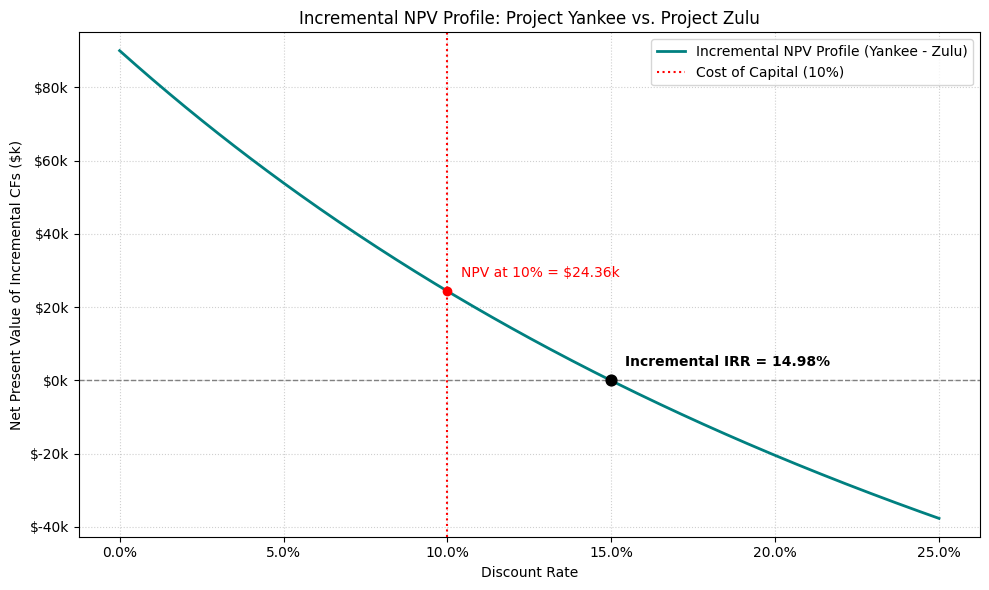

INCREMENTAL ANALYSIS (YANKEE - ZULU)
NPV of Incremental Cash Flows at 10% Cost of Capital: $24.36k
Incremental IRR: 14.98%
------------------------------------------------------------
Decision Rule: Since the Incremental IRR (~14.98%) > Cost of Capital (10%),
the additional $190k investment required for Project Yankee generates a sufficient return.
Therefore, Project Yankee is preferred over Project Zulu.


In [12]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# --- Incremental Cash Flows (Yankee - Zulu) ---
# Year 0: -400 - (-210) = -190
# Year 1:  150 - 110 = 40
# Year 2:  150 - 90 = 60
# Year 3:  150 - 70 = 80
# Year 4:  150 - 50 = 100
incremental_cash_flows = np.array([-190.0, 40.0, 60.0, 80.0, 100.0])

# --- Parameters ---
cost_of_capital = 0.10  # 10% Cost of Capital

# --- Define NPV Function ---
def calculate_npv(rate, cashflows):
    """Calculates the Net Present Value of a series of cash flows."""
    if rate <= -1.0:
        return np.nan 
    npv = 0.0
    for t, cf in enumerate(cashflows):
        npv += cf / ((1 + rate) ** t)
    return npv

# --- Calculate IRRs using Polynomial Root Finding ---
# We solve for x = 1/(1+r) using the reverse of the cash flow array
coefficients = incremental_cash_flows[::-1] 

try:
    roots = np.roots(coefficients)

    # Filter for real roots where x = 1/(1+r) is positive
    real_roots_x = roots[np.isreal(roots)].real
    positive_real_roots_x = real_roots_x[real_roots_x > 1e-9]

    if len(positive_real_roots_x) == 0:
        print("No positive real roots found. No meaningful IRR.")
        incremental_irrs = []
    else:
        # Convert x back to r: r = (1/x) - 1
        all_real_irrs = (1 / positive_real_roots_x) - 1
        # Filter for positive IRRs
        incremental_irrs = [irr for irr in all_real_irrs if irr > 1e-9]

except np.linalg.LinAlgError:
    print("Error calculating roots. Could not determine IRRs.")
    incremental_irrs = []

# --- Generate Data for NPV Profile Plot ---
min_rate = 0.0
max_rate = 0.25 # 25% to comfortably show the ~15% IRR
n_points = 300
discount_rates = np.linspace(min_rate, max_rate, n_points)

# Calculate NPV for each discount rate
npv_values = [calculate_npv(rate, incremental_cash_flows) for rate in discount_rates]

# --- Create the Plot ---
plt.figure(figsize=(10, 6))
plt.plot(discount_rates, npv_values, label='Incremental NPV Profile (Yankee - Zulu)', color='teal', linewidth=2)

# Add horizontal line at NPV = 0
plt.axhline(0, color='grey', linestyle='--', linewidth=1)

# Add vertical line at the cost of capital (10%)
npv_at_coc = calculate_npv(cost_of_capital, incremental_cash_flows)
plt.axvline(cost_of_capital, color='red', linestyle=':', linewidth=1.5, label=f'Cost of Capital ({cost_of_capital:.0%})')
plt.scatter(cost_of_capital, npv_at_coc, color='red', zorder=5)
plt.annotate(f'NPV at 10% = ${npv_at_coc:.2f}k', 
             xy=(cost_of_capital, npv_at_coc), xytext=(10, 10), 
             textcoords='offset points', color='red')

# Mark the calculated POSITIVE IRRs on the plot
if len(incremental_irrs) > 0:
    valid_irrs_in_range = [irr for irr in incremental_irrs if min_rate <= irr <= max_rate]
    if valid_irrs_in_range:
        for irr in valid_irrs_in_range:
            plt.scatter(irr, 0, color='black', zorder=5, s=60)
            plt.annotate(f'Incremental IRR = {irr:.2%}', 
                         xy=(irr, 0), xytext=(10, 10), 
                         textcoords='offset points', color='black', fontweight='bold')

# Add labels and title
plt.xlabel("Discount Rate")
plt.ylabel("Net Present Value of Incremental CFs ($k)")
plt.title("Incremental NPV Profile: Project Yankee vs. Project Zulu")

# Format axes
plt.gca().yaxis.set_major_formatter(mtick.FormatStrFormatter('$%.0fk'))
plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

# Add grid and legend
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()

# Adjust padding
min_npv = min(v for v in npv_values if not np.isnan(v))
max_npv = max(v for v in npv_values if not np.isnan(v))
plt.ylim(min_npv - 5, max_npv + 5)

# Show the plot
plt.tight_layout()
plt.show()

# --- Print Analysis Console Output ---
print("="*60)
print("INCREMENTAL ANALYSIS (YANKEE - ZULU)")
print("="*60)
print(f"NPV of Incremental Cash Flows at {cost_of_capital:.0%} Cost of Capital: ${npv_at_coc:.2f}k")

if len(incremental_irrs) > 0:
    for i, irr_val in enumerate(incremental_irrs):
        print(f"Incremental IRR: {irr_val:.2%}")
else:
     print("No positive IRRs found.")
        
print("-" * 60)
print("Decision Rule: Since the Incremental IRR (~14.98%) > Cost of Capital (10%),")
print("the additional $190k investment required for Project Yankee generates a sufficient return.")
print("Therefore, Project Yankee is preferred over Project Zulu.")
print("="*60)

---

### What is next?

* Problem Set 3

* Fundamentals of Capital Budgeting
    *   Reading(s):
    
    *   CF-B&D: Ch. 8

---